# 46 — Trace the combined FRTB calculation from capital to trades

Make every reported amount traceable through desks, model stages, factors and positions.

The reporting layer does not create capital. It presents retained calculation outputs from the same run in a compact form.

This step uses: The combined capital summary, desk results, IMCC stages, NMRFs, default tail simulations and run manifest.

It produces: A capital summary and drill-down map suitable for the reporting workbook and repository outputs.

> Basel norm applied: MAR30 model validation expects transparent and accessible data flows, model inputs and calculations.

$$Capital\rightarrow Desk\rightarrow Measure\rightarrow Scenario\rightarrow Factor\rightarrow Trade$$

Synthetic inputs are labelled directly in the displayed data. Basel regulatory parameters are loaded separately from versioned configuration.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from frtb_engine.notebook_tools import INR_CRORE, configure_notebooks, crore_table, draw_flow, heatmap

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_ima_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
MANIFEST = json.loads((RUN / 'run_manifest.json').read_text(encoding='utf-8'))
STAGES = {row['stage']: ROOT / row['path'] for row in MANIFEST['artifacts']}
SUMMARY = json.loads((RUN / '27_combined_capital_summary.json').read_text(encoding='utf-8'))

def stage(name):
    return pd.read_csv(STAGES[name])

def money(value):
    return f"INR {float(value) / INR_CRORE:,.2f} crore"

print(f'IMA calculation run used: {RUN_ID}')
print('Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled')

IMA calculation run used: IMA_20260901T122303Z
Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled


In [2]:
desk=stage('25_desk_capital_summary'); manifest=pd.DataFrame(MANIFEST['artifacts'])
capital_columns=['sa_capital_inr','ima_component_inr','amber_surcharge_inr','sa_fallback_component_inr','final_capital_treatment_inr']
display(crore_table(desk[['desk','final_treatment',*capital_columns]],capital_columns))
display(manifest[['stage','rows','path']])
print(f"The run retains {len(manifest)} calculation artifacts. Every capital amount can be followed to its dated scenarios, factors and trades.")

,desk,final_treatment,Sa Capital (INR crore),Ima Component (INR crore),Amber Surcharge (INR crore),Sa Fallback Component (INR crore),Final Capital Treatment (INR crore)
0,Commodity,IMA_GREEN,35.7561,27.9900,0.0000,0.0000,27.9900
1,Credit,IMA_GREEN,26.7431,20.9346,0.0000,0.0000,20.9346
2,Equity,IMA_GREEN,36.4942,28.5678,0.0000,0.0000,28.5678
3,FX,IMA_GREEN,5.5035,4.3081,0.0000,0.0000,4.3081
4,Rates,IMA_GREEN,8.8352,6.9162,0.0000,0.0000,6.9162
5,Residual Risk,SA_FALLBACK,0.0800,0.0000,0.0000,0.0800,0.0800


,stage,rows,path
0,01_ima_factor_inventory,59,outputs/IMA_20260901T122303Z/01_ima_factor_inv...
1,02_synthetic_rpo_observations,4410,outputs/IMA_20260901T122303Z/02_synthetic_rpo_...
2,03_rfet_results,59,outputs/IMA_20260901T122303Z/03_rfet_results.csv
3,04_synthetic_factor_history,153872,outputs/IMA_20260901T122303Z/04_synthetic_fact...
4,05_factor_exposures,121,outputs/IMA_20260901T122303Z/05_factor_exposur...
5,06_daily_factor_pnl,315568,outputs/IMA_20260901T122303Z/06_daily_factor_p...
6,07_reduced_factor_selection,51,outputs/IMA_20260901T122303Z/07_reduced_factor...
7,08_stress_window_scan,2359,outputs/IMA_20260901T122303Z/08_stress_window_...
8,09_es_summary,24,outputs/IMA_20260901T122303Z/09_es_summary.csv
9,10_liquidity_horizon_es_components,120,outputs/IMA_20260901T122303Z/10_liquidity_hori...


The run retains 28 calculation artifacts. Every capital amount can be followed to its dated scenarios, factors and trades.


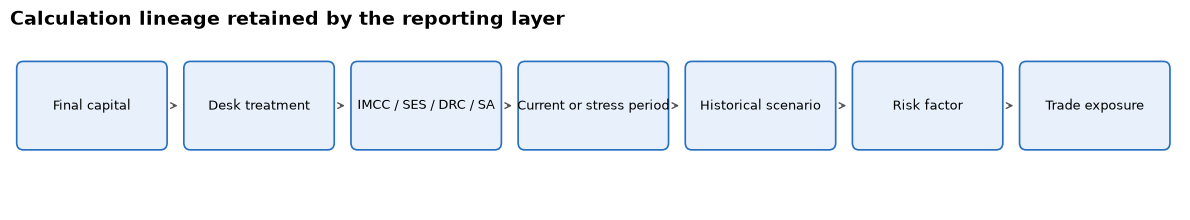

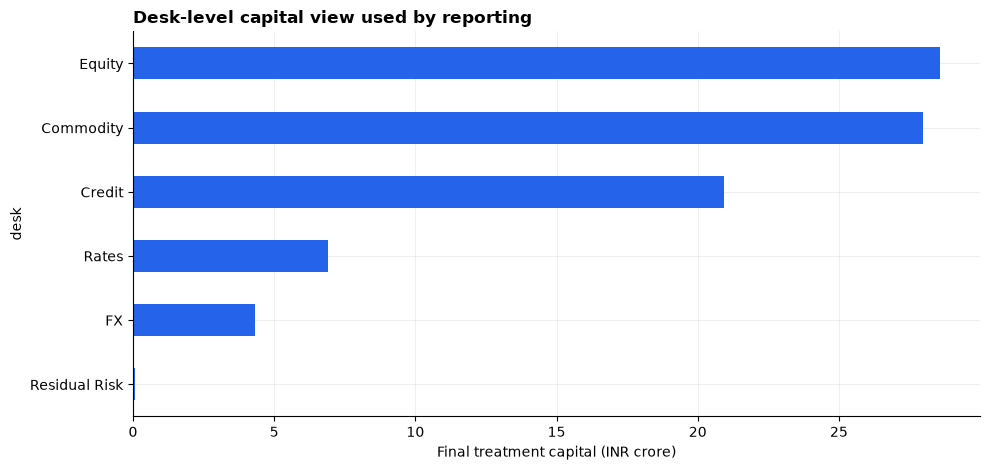

In [3]:
draw_flow(['Final capital','Desk treatment','IMCC / SES / DRC / SA','Current or stress period','Historical scenario','Risk factor','Trade exposure'],'Calculation lineage retained by the reporting layer',wrap_after=7)
ax=(desk.set_index('desk').final_capital_treatment_inr/INR_CRORE).sort_values().plot(kind='barh',color='#2563EB'); ax.set_xlabel('Final treatment capital (INR crore)'); ax.set_title('Desk-level capital view used by reporting',loc='left',weight='bold'); plt.tight_layout(); plt.show()

The lineage diagram reads from the reported capital amount back through desk treatment, capital measure, period, scenario, factor and trade exposure. The horizontal bar chart shows the final capital treatment by desk. It makes clear which desks dominate the reported total after each desk has been assigned either IMA or SA fallback.